## Bibliothèques

In [1]:
# faire varier le nœud
# afficher le apha_x, beta_x, kappa_t
# le mae moyen
# faire stocker les résultats dans un tableau 
# faire varier les point des Bsplines

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))
import geopandas as gpd
import sys
sys.executable
import numpy as np

#### librairie "morta_nuts2" construite

In [3]:
from morta_nuts2.data.eurostat import*
from morta_nuts2.data.mortality_table import*
from morta_nuts2.model.Bsplines.Bsplines import make_bspline_basis
from morta_nuts2.model.parameters_init.param_init import*
from morta_nuts2.model.projection.project_class import*
from morta_nuts2.model.LC_p.lcp_class import*
from morta_nuts2.model.LL_p.llp_class import*
from morta_nuts2.graph.plot_class import*

In [4]:
# #from morta_nuts2.data.raw_data import*
# #from morta_nuts2.data.raw import*
# #from morta_nuts2.data.processed import*
# from morta_nuts2.model.Brouillon.lc_p import LCp_fit, LC_fit, build_input_from_dataframe,LCp_multiregion_fit
# #from morta_nuts2.model.LC.lc import
# from morta_nuts2.model.Brouillon.ll_p import LiLee_p_fit, LandL_fit



### Test fonctions imports de data eurostat

In [5]:

# Option 1: Le chemin par défaut est déjà bon : sans path ils stock dans la data dans le lieu ou se trouve votre script

# Option 2: Changer le chemin par défaut pour toute l'application
#EurostatConfig.set_default_shapefile("D:/mes_donnees/NUTS_2024.shp") # implémenter par defaut mais possible de le changer
EurostatConfig.set_default_data_path("C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data")

data_brute = Eurostat_data()

#Chargement des données - ultra simple
mortality_fr = data_brute.load("mortality", "FR")
deaths_fr = data_brute.load("deaths", "FR")
population_fr = data_brute.load("population", "FR")


#Tout charger d'un coup en dictionnaire
#data_fr = data_brute.load_all("FR")




📂 Loading NUTS shapefile... NUTS_RG_01M_2024_3035.shp
✅ Shapefile loaded (1798 features)
💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


In [6]:
#data_fr = data_brute.load_all("FR")

### Test function for data create

In [7]:
morta = MortalityCalculator()
table = morta.calculate_mortality(mortality_fr,population_fr,deaths_fr,gender="T")

2026-03-13 12:36:19,906 - MortalityCalculator - INFO - Loading shapefile: C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp
2026-03-13 12:36:20,157 - MortalityCalculator - INFO - 1793 regions loaded
2026-03-13 12:36:20,172 - MortalityCalculator - INFO - MortalityCalculator initialized with 1793 regions
2026-03-13 12:36:20,173 - MortalityCalculator - INFO - Validating input data...
2026-03-13 12:36:24,716 - MortalityCalculator - INFO - Validation successful
2026-03-13 12:36:24,717 - root - INFO - validate_input_data executed in 4.54 seconds
2026-03-13 12:36:24,729 - MortalityCalculator - INFO - Result retrieved from cache
2026-03-13 12:36:24,730 - root - INFO - calculate_mortality executed in 4.56 seconds


In [8]:
table = table[table['year'] != 2024]

In [9]:
#données d'entrée modèles
dictio = build_input_from_dataframe(table)
#dictio

In [10]:
#test_table_by_age = mortality_by_region_by_age(mortality_fr,population_fr,deaths_fr,regions)
#test_table_by_age

#### Paramètres

In [11]:
Muxtg,Dxtg, Extg, xv, tv, regions = build_input_from_dataframe(table)

print("Shape Dxtg :", Dxtg.shape)
print("Shape Extg :", Extg.shape)
print("Shape Muxtg :", Muxtg.shape)
print("Ages :", len(xv))
print("Years :", len(tv))
print("Regions :", len(regions))
nb_regions = len(regions)
nb_years = len(tv)
degree = 3
n_knots = 25
nb_iter = 5000
lam = 0
Dxt = np.sum(Dxtg, axis=2)
Ext = np.sum(Extg, axis=2)


Shape Dxtg : (83, 34, 22)
Shape Extg : (83, 34, 22)
Shape Muxtg : (83, 34, 22)
Ages : 83
Years : 34
Regions : 22


#### modèle Lee carter 

###### modèle Lee carter non paramétrique

In [12]:

#LC initial values
ax_init   = -0.001*np.zeros_like(xv)
bx_init   = 0.001*np.ones_like(xv)
kappa_init= np.ones(len(tv))
# nb parameters
#nb_params_LC = len(ax_init)*2 + len(common_years)
#LC fit
#result_lc = LC_fit(ax_init,bx_init,kappa_init,Extg,Dxtg,xv,tv,nb_iter_LC)

In [13]:
model_classic = LeeCarter.Classic(nb_iter=nb_iter, eta=1)

results_lc_classic = model_classic.fit(
    ax     = ax_init,
    bx     = bx_init,
    kappa  = kappa_init,
    Extg   = Extg,
    Dxtg   = Dxtg,
    xv     = xv,
    tv     = tv,
)

In [14]:
results_lc_classic['fit_statistics']

,N,m,degree,dofs,lnL,AIC,BIC
0,62084,NA,NA,200,-282530.49,565460.97,567268.22


###### modèle Lee carter paramétrique

In [15]:
_, _, n_basis = make_bspline_basis(
    xv, degree, n_knots)

In [16]:
ax_coef_init, bx_coef_init, kappa_init = lcp_parametrique_init_national(
    Dxtg, Extg, xv, tv, n_basis=n_basis, degree=degree, n_knots=n_knots
)

# results = LCp_fit(
#     ax_coef_init  = ax_coef_init,
#     bx_coef_init  = bx_coef_init,
#     kappa_init    = kappa_init,
#     Extg=Extg, Dxtg=Dxtg,
#     xv=xv, tv=tv,
#     degree=2, n_knots=10,
#     lam=1.0,
#     verbose=True
# )

In [17]:
# 
model_nat = LeeCarter.Parametric.National(
    degree=degree,
    n_knots=n_knots,
    lam=lam,
    nb_iter=nb_iter,
    eta0=0.2,
    tol=1e-4,
    verbose=True,
)

results_lcp_nat = model_nat.fit(
    ax_coef_init  = ax_coef_init,
    bx_coef_init  = bx_coef_init,
    kappa_init    = kappa_init,
    Extg          = Extg,
    Dxtg          = Dxtg,
    xv            = xv,
    tv            = tv,)

It    0 | lnL = -284711.5040 | Δ = +inf | η = 0.20000
It   10 | lnL = -283007.8538 | Δ = +6.259881 | η = 0.32578
It   20 | lnL = -282992.7944 | Δ = +0.588005 | η = 0.53066
It   30 | lnL = -282989.7950 | Δ = +0.142542 | η = 0.86439
It   40 | lnL = -282989.1866 | Δ = +0.020523 | η = 1.40800
It   50 | lnL = -282989.1285 | Δ = +0.000000 | η = 1.00000

Convergence reached (tolerance) at it 50.

FINAL STATISTICS
    N  n_basis  dofs        lnL      deviance       AIC       BIC
62084       27  88.0 -282989.13 -1.103963e+08 566154.26 566949.45


#### Modèle Lee and Li

###### modèle Lee and Li non paramétrique

In [18]:
#------------------------------------------------------------------------------
bx_gr_init    =   0.0000010*np.ones((len(xv),len(regions)))
kappa_gr_init =   0.0000010*np.ones((len(tv),len(regions)))


In [19]:
model_c = LiLee.Classic(nb_iter=nb_iter,
                         verbose=False)

result_ll = model_c.fit(
    ax       = ax_init,
    bx       = bx_init,
    bx_gr    = bx_gr_init,
    kappa    = kappa_init,
    kappa_gr = kappa_gr_init,
    Extg     = Extg,
    Dxtg     = Dxtg,
    Muxtg    = Muxtg,
    xv       = xv,
    tv       = tv,
)

In [20]:
result_ll['fit_statistics']

,N,m,degree,dofs,lnL,AIC,BIC
0,62084,NA,NA,2750,-215387.22,436274.44,461124.11


###### modèle Lee and Li paramétrique

In [21]:


#Construction base spline pour connaître n_basis
B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

ax_coef_init = np.zeros(n_basis)
bx_coef_init = np.ones((len(regions), n_basis))
kappa_init =  np.ones(len(tv))

In [30]:
model_multi = LiLee.Parametric.LeeAndLi(
    degree=degree,
    n_knots=n_knots,
    lam=lam,
    nb_iter=5000,
    eta0=0.2,
    tol=1e-3,
    verbose=True,
)

result_llp = model_multi.fit(
    ax_coef_init  = ax_coef_init,
    bx_coef_init  = bx_coef_init,
    kappa_init    = kappa_init,
    Extg          = Extg,
    Dxtg          = Dxtg,
    xv            = xv,
    tv            = tv,)

It    0 | lnL = -9918764202.1432 | Δ = +inf | η = 0.21000
It   10 | lnL = -849666.3227 | Δ = +731310.795411 | η = 0.34207
It   20 | lnL = -262140.4326 | Δ = -657.205178 | η = 0.55719
It   30 | lnL = -256698.4660 | Δ = +270.647410 | η = 0.20581
It   40 | lnL = -253271.3627 | Δ = +408.304515 | η = 0.33524
It   50 | lnL = -248242.4339 | Δ = +584.455716 | η = 0.54607
It   60 | lnL = -241413.9235 | Δ = +756.319662 | η = 0.88949
It   70 | lnL = -233394.5064 | Δ = +809.851056 | η = 1.44888
It   80 | lnL = -5573319.1954 | Δ = +13222741.122495 | η = 0.25484
It   90 | lnL = -231817.3935 | Δ = +267.935247 | η = 0.41511
It  100 | lnL = -229514.8993 | Δ = +155.292047 | η = 0.67617
It  110 | lnL = -228183.9887 | Δ = +83.697343 | η = 0.24975
It  120 | lnL = -227153.3683 | Δ = +119.886613 | η = 0.40682
It  130 | lnL = -225741.9640 | Δ = +157.842706 | η = 0.66266
It  140 | lnL = -224017.7641 | Δ = +180.096267 | η = 1.07941
It  150 | lnL = -222781.7899 | Δ = +235.160715 | η = 0.18985
It  160 | lnL = -22

###### modèle Lee and Li variant avec Bsplines paramétrique

In [23]:
#resultat_llp["fit_statistics"]

In [24]:
model_p = LiLee.Parametric.FullModel(
    degree=degree,
    n_knots=n_knots,
    lam=lam,
    nb_iter=nb_iter,
    eta0=0.20,
    tol=1e-4,
    verbose=True,
)

alpha_coef_init, beta_coef_init, beta_g_coef_init, kappa_init, kappa_g_init = model_p.init_params(Dxtg,
                                                                                                   Extg, xv)

In [25]:
result_llp_variant = model_p.fit(
    alpha_coef_init  = alpha_coef_init,
    beta_coef_init   = beta_coef_init,
    beta_g_coef_init = beta_g_coef_init,
    kappa_init       = kappa_init,
    kappa_g_init     = kappa_g_init,
    Extg             = Extg,
    Dxtg             = Dxtg,
    xv               = xv,
    tv               = tv,
)

PARAMETRIC LI-LEE MODEL CALIBRATION
Parameters: degree=3, n_knots=25, lam=0
Data: 83 ages × 34 years × 22 regions
Number of basis functions: 27
It    0 | lnL = -554,523.18 | Δ = -554523.180626 | η = 0.10000
It   10 | lnL = -230,759.07 | Δ = +5267.963633 | η = 0.07757
It   20 | lnL = -215,601.39 | Δ = +383.068513 | η = 0.12635
It   30 | lnL = -213,900.63 | Δ = +93.080946 | η = 0.20581
It   40 | lnL = -213,084.88 | Δ = +83.463897 | η = 0.33524
It   50 | lnL = -212,181.57 | Δ = +91.481454 | η = 0.54607
It   60 | lnL = -211,361.22 | Δ = +66.683805 | η = 0.88949
It   70 | lnL = -229,056.28 | Δ = -17532.018862 | η = 0.68994
It   80 | lnL = -211,869.31 | Δ = +80.404690 | η = 0.25484
It   90 | lnL = -211,318.80 | Δ = +44.186325 | η = 0.41511
It  100 | lnL = -210,972.86 | Δ = +27.358428 | η = 0.67617
It  110 | lnL = -210,769.53 | Δ = +15.397899 | η = 1.10140
It  120 | lnL = -211,441.42 | Δ = +1066.571529 | η = 0.19372
It  130 | lnL = -213,751.97 | Δ = -117.034481 | η = 0.00040
It  140 | lnL = -

##### MAE & WMAE

In [35]:
mae_llp = compute_mae(Muxtg, result_llp['fitted_values']['mu'], weights=Extg)
mae_llp_variant = compute_mae(Muxtg, result_llp_variant['fitted_values']['mu'], weights=Extg)
mae_lcp = compute_mae(Dxt/Ext, results_lcp_nat['fitted_values']['mu'], weights=Extg)

print(f"MAE  global — LC : {mae_llp['global']:.6f} | LL : {mae_llp_variant['global']:.6f}")
print(f"WMAE global — LC : {mae_llp['wmae_global']:.6f} | LL : {mae_llp_variant['wmae_global']:.6f}")

MAE  global — LC : 0.000485 | LL : 0.000474
WMAE global — LC : 0.000314 | LL : 0.000296


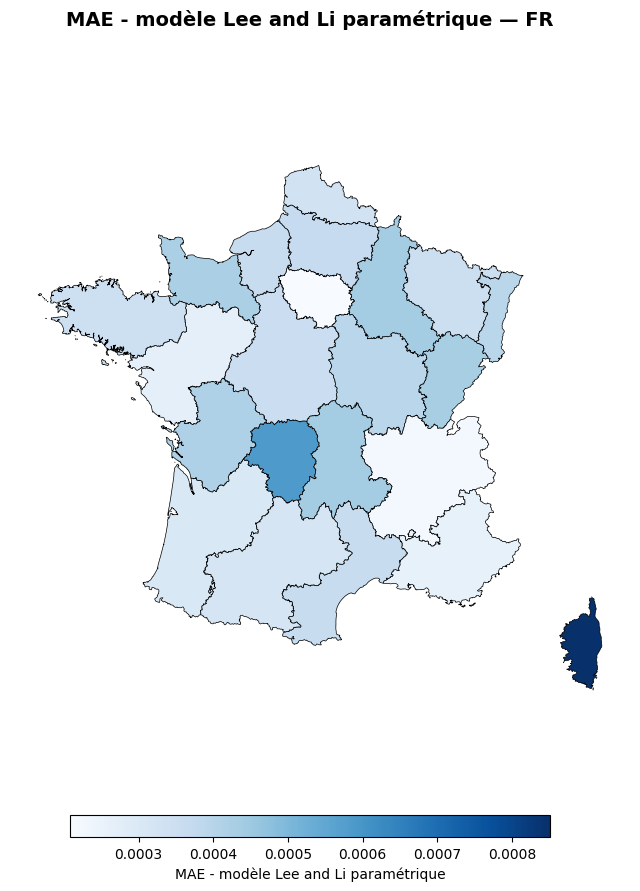

In [27]:
tv_future = np.arange(1990, 2024) #années
mp = MapPlotter(regions, mae_llp['wmae_by_region'], tv_future, "FR", "MAE - modèle Lee and Li paramétrique")
mp.plot_static(mae_llp['wmae_by_region'])

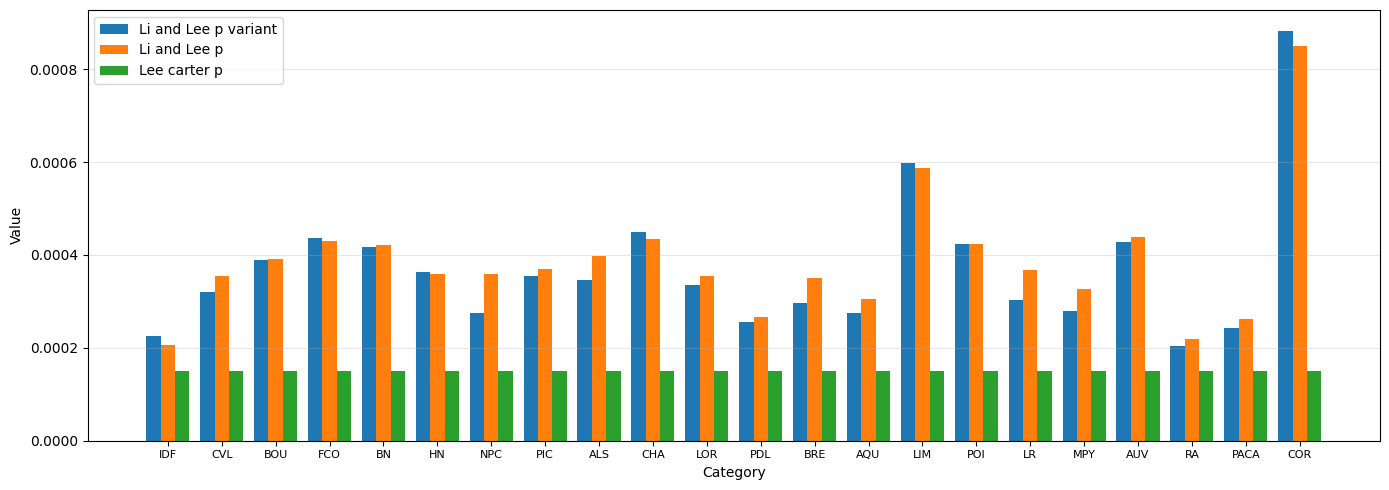

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# --- Tes arrays de MAE par modèle ---
mae = {
    "Li and Lee p variant":  mae_llp_variant['wmae_by_region'] ,  # ton array
    "Li and Lee p":      mae_llp['wmae_by_region'],
     "Lee carter p": mae_lcp["wmae_global"] }
    
# -------- abbreviation of NUTS 2 regions --------
# Bel_nuts2 = {
#     "BE10": "BXL",
#     "BE21": "ANT",
#     "BE22": "LIM",
#     "BE23": "OVL",
#     "BE24": "VlB",
#     "BE25": "WVl",
#     "BE31": "BWA",
#     "BE32": "HAI",
#     "BE33": "LIE",
#     "BE34": "LUX",
#     "BE35": "NAM"
# }


France_nuts2 = {
    "FR10": "IDF", "FRB0": "CVL", "FRC1": "BOU", "FRC2": "FCO",
    "FRD1": "BN",  "FRD2": "HN",  "FRE1": "NPC", "FRE2": "PIC",
    "FRF1": "ALS", "FRF2": "CHA", "FRF3": "LOR", "FRG0": "PDL",
    "FRH0": "BRE", "FRI1": "AQU", "FRI2": "LIM", "FRI3": "POI",
    "FRJ1": "LR",  "FRJ2": "MPY", "FRK1": "AUV", "FRK2": "RA",
    "FRL0": "PACA","FRM0": "COR"
}
region_labels = list(France_nuts2.values())

models  = list(mae.keys())
colors  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # bleu, orange, vert, rouge
n       = len(region_labels)
n_models = len(models)
width   = 0.8 / n_models  # barres qui se touchent presque
x       = np.arange(n)

fig, ax = plt.subplots(figsize=(14, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(x + offset, mae[model], width, label=model, color=color)

ax.set_xticks(x)
ax.set_xticklabels(region_labels, rotation=0, fontsize=8)
ax.set_xlabel("Category")
ax.set_ylabel("Value")
ax.legend()
ax.grid(axis="y", alpha=0.3)
#ax.set_title("Histogram of weighted mean absolute errors by regions, France.")

plt.tight_layout()
plt.show()

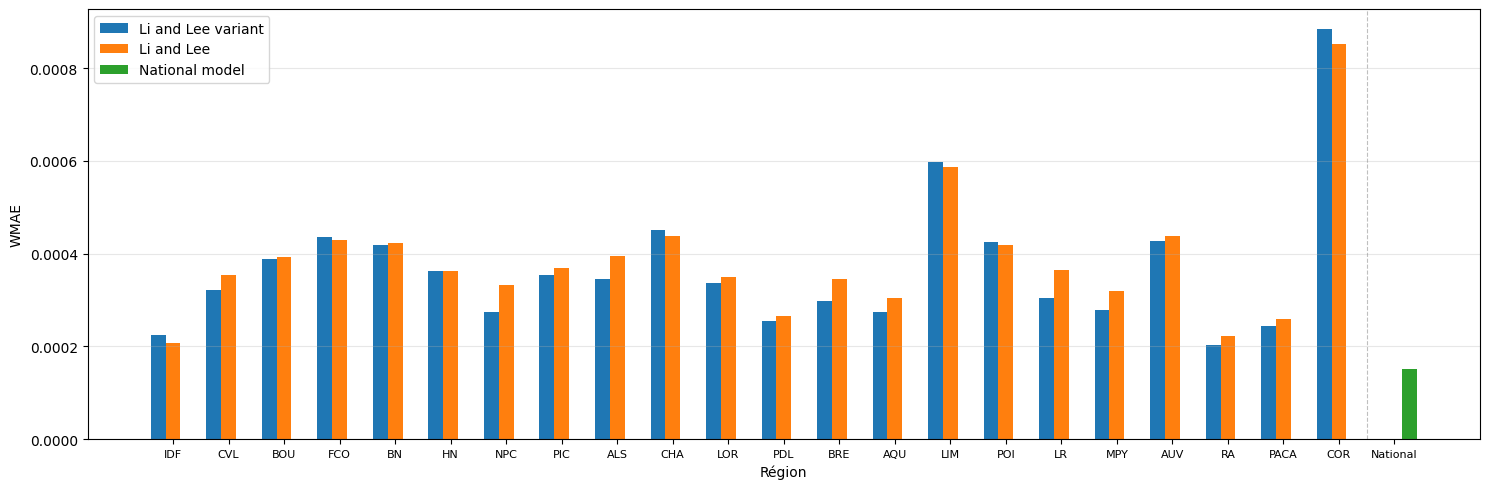

In [31]:
import matplotlib.pyplot as plt
import numpy as np

mae_regional = {
    "Li and Lee variant": mae_llp_variant['wmae_by_region'],  # (nb_regions,)
    "Li and Lee":         mae_llp['wmae_by_region'],          # (nb_regions,)
}

mae_national = {
    "National model": mae_lcp['wmae_global'],  # scalaire
}

France_nuts2 = {
    "FR10": "IDF", "FRB0": "CVL", "FRC1": "BOU", "FRC2": "FCO",
    "FRD1": "BN",  "FRD2": "HN",  "FRE1": "NPC", "FRE2": "PIC",
    "FRF1": "ALS", "FRF2": "CHA", "FRF3": "LOR", "FRG0": "PDL",
    "FRH0": "BRE", "FRI1": "AQU", "FRI2": "LIM", "FRI3": "POI",
    "FRJ1": "LR",  "FRJ2": "MPY", "FRK1": "AUV", "FRK2": "RA",
    "FRL0": "PACA","FRM0": "COR"
}
region_labels = list(France_nuts2.values())

all_models  = list(mae_regional.keys()) + list(mae_national.keys())
n_models    = len(all_models)
colors      = ["#1f77b4", "#ff7f0e", "#2ca02c"]
width       = 0.8 / n_models
n           = len(region_labels)
x           = np.arange(n + 1)  # +1 pour la colonne nationale

fig, ax = plt.subplots(figsize=(15, 5))

# --- Barres régionales ---
for i, (model, color) in enumerate(zip(mae_regional.keys(), colors)):
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(x[:n] + offset, mae_regional[model], width, label=model, color=color)

# --- Barre nationale (même width, même style) ---
for i, (model, value) in enumerate(mae_national.items()):
    model_idx = len(mae_regional) + i
    offset = (model_idx - n_models / 2 + 0.5) * width
    ax.bar(x[-1] + offset, value, width, label=f"{model}", color=colors[model_idx])

# Ligne verticale de séparation
ax.axvline(n - 0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

xtick_labels = region_labels + ["National"]
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=0, fontsize=8)
ax.set_xlabel("Région")
ax.set_ylabel("WMAE")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

##### Graphiques

In [40]:
mu_obs = Dxtg / Extg
curves = {
    "Observed": mu_obs,
    "LCp": result_llp['fitted_values']['mu'],
    "LL": result_ll["fitted_values"]["mu"],
    "LL_p": result_llp_variant["fitted_values"]["mu"]}

In [41]:
# alpha_x = result_lcp["curves"]["alpha_x"]
# beta_x  = result_lcp["curves"]["beta_x"]
mu_fit  = results_lcp_nat['fitted_values']['mu']  # (age, year)

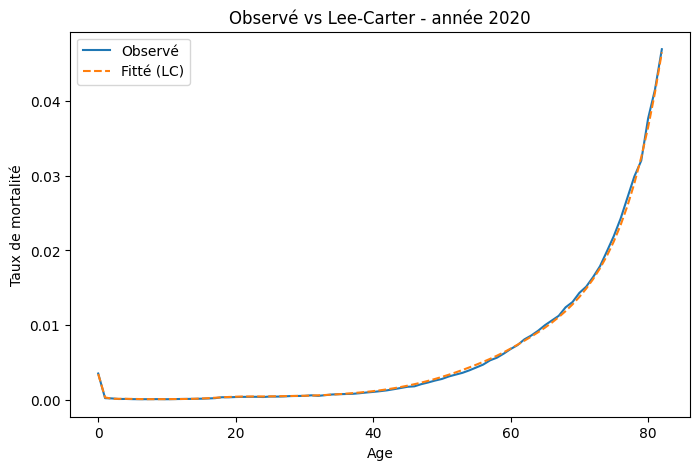

In [42]:
mu_obs = Dxt / np.maximum(Ext, 1e-12)
import matplotlib.pyplot as plt

t_index = -4  # dernière année

plt.figure(figsize=(8,5))

plt.plot(xv, mu_obs[:, t_index], label="Observé")
plt.plot(xv, mu_fit[:, t_index], label="Fitté (LC)", linestyle="--")

plt.xlabel("Age")
plt.ylabel("Taux de mortalité")
plt.title(f"Observé vs Lee-Carter - année {tv[t_index]}")
plt.legend()
plt.show()

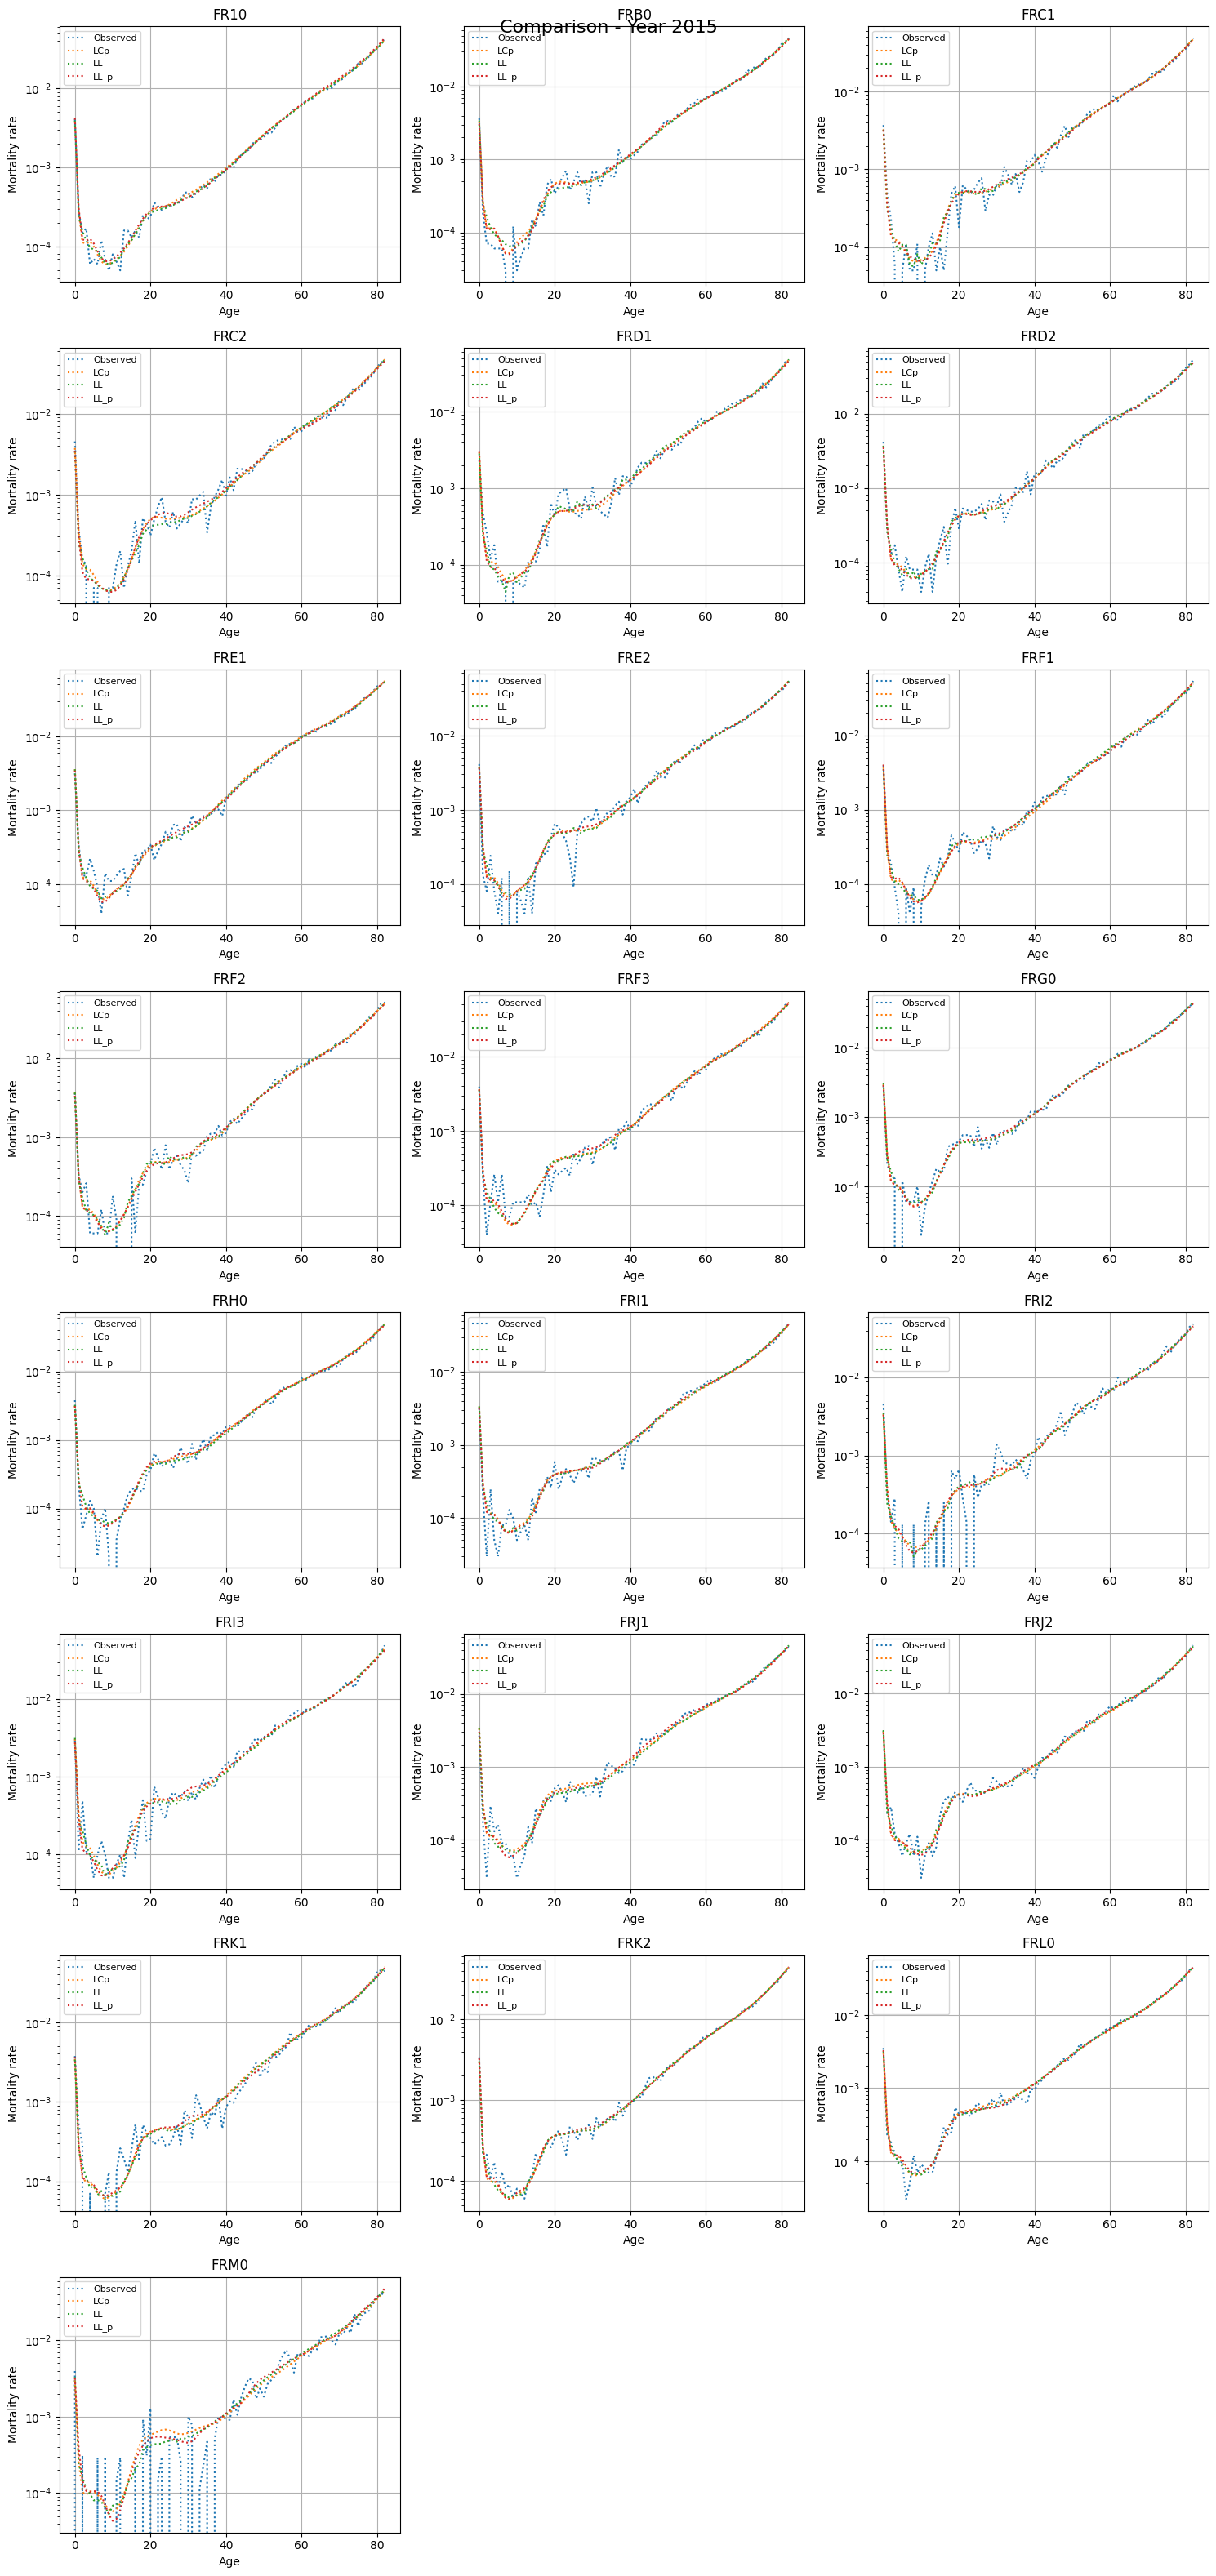

In [43]:
# ── RegionalCurvePlotter ────────────────────────────────────────────
plotter = RegionalCurvePlotter(
    x_values=xv,
    curves_dict=curves,
    tv=tv,
    regions=regions,
)
plotter.plot(year_to_plot=2015)

### Projector

###### Lee Carter and Lee and Li

In [44]:
n_sim = 2000
horizon = 27
covid_years = ['2019','2020',"2021"]

In [ ]:
proj_llp_stoch = ProjectorLC_SVD(
    result_llp, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=False,
    n_sim=n_sim,
).project()

In [46]:
kappa_LC_national = ProjectorLC_SVD(
    results_lcp_nat, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=False,
    n_sim=n_sim,
)
a,b = kappa_LC_national._svd_factors()

In [48]:
# kapa = kappa_LC_national._project_rw(a,b)
# logmu_lc_national = (
#     results_lcp_nat['curves']['alpha_x'][:, None, None, None]   # (83, 1, 1, 1)
#     + results_lcp_nat['curves']['beta_x'][:, None, None, None]  # (83, 1, 1, 1)
#     * kapa.transpose(0, 2, 1)[None, :, :, :]            # (1, 27, 1, 2000)
# )
# # logmu → (83, 27, 1, 2000)

###### Lee and Li variant

In [ ]:
proj_llp_variant_stoch = ProjectorLeeLi(
    result_llp_variant, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=False,
    n_sim=n_sim,
).project()

##### HighAgeExtrapolator

In [65]:
start_age = 60

In [66]:
# logmu_nation_lcp, xv_full = HighAgeExtrapolator(
#     xv          = xv,
#     x_extrap    = 110,          # âge cible
#     x_extrap_start = start_age,        # début de la fenêtre de régression commencer à 60 ans 
#     method="linear",
#     log_Muxtg   = logmu_lc_national, auto_start =False).extrapolate()
    

# # logmu_extrap
# # xv_full      → [0, 1, ..., 110]

# print("log-mu extrapolé :", logmu_nation_lcp.shape)   
# print("Grille d'âges    :", xv_full[[0, -1]]) 

In [ ]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_llp, xv_full = HighAgeExtrapolator(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression commencer à 60 ans 
    method="linear",
    log_Muxtg   = proj_llp_stoch["logmu_future"], auto_start =False).extrapolate()
    

# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_llp.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])  

log-mu extrapolé : (111, 27, 22)
Grille d'âges    : [  0 110]


In [ ]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_llp_variant, xv_full = HighAgeExtrapolator(
                    xv          = xv,
                    x_extrap    = 110,          # âge cible
                    x_extrap_start = start_age,        # début de la fenêtre de régression
                    method="linear",
                    log_Muxtg   = proj_llp_variant_stoch["logmu_future"],auto_start =False
                ).extrapolate()
# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_llp_variant.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])      

log-mu extrapolé : (111, 27, 22)
Grille d'âges    : [  0 110]


In [69]:
# ── 2. Extrapolation 82 → 110 ## Lee carter paramétrique
logmu_llp_hist, xv_full = HighAgeExtrapolator(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression
    method="linear",
    log_Muxtg   = result_llp["fitted_values"]["log_mu"],auto_start =False
).extrapolate()
# logmu_extrap 
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_llp_hist.shape)  
print("Grille d'âges    :", xv_full[[0, -1]])      # [  0 110]

log-mu extrapolé : (111, 34, 22)
Grille d'âges    : [  0 110]


In [70]:
# ── 2. Extrapolation 82 → 110 ## Lee carter paramétrique
logmu_llp_hist_variant, xv_full = HighAgeExtrapolator(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression
    method="linear",
    log_Muxtg   = result_llp_variant["fitted_values"]["log_mu"],auto_start =False
).extrapolate()
# logmu_extrap 
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_llp_hist_variant.shape)  
print("Grille d'âges    :", xv_full[[0, -1]])      # [  0 110]

log-mu extrapolé : (111, 34, 22)
Grille d'âges    : [  0 110]


In [71]:
logmu_full_llp = concat_logmu_time(logmu_llp_hist,logmu_extrap_llp)
logmu_full_llp_variant = concat_logmu_time(logmu_llp_hist_variant,logmu_extrap_llp_variant)

In [72]:
print(logmu_full_llp.shape)
print(logmu_full_llp_variant.shape)

(111, 61, 22)
(111, 61, 22)


#### LifeExpectancy

In [75]:
esp_llp = LifeExpectancy(np.exp(logmu_full_llp)).compute()
esp_llp_variant = LifeExpectancy(np.exp(logmu_full_llp_variant)).compute()

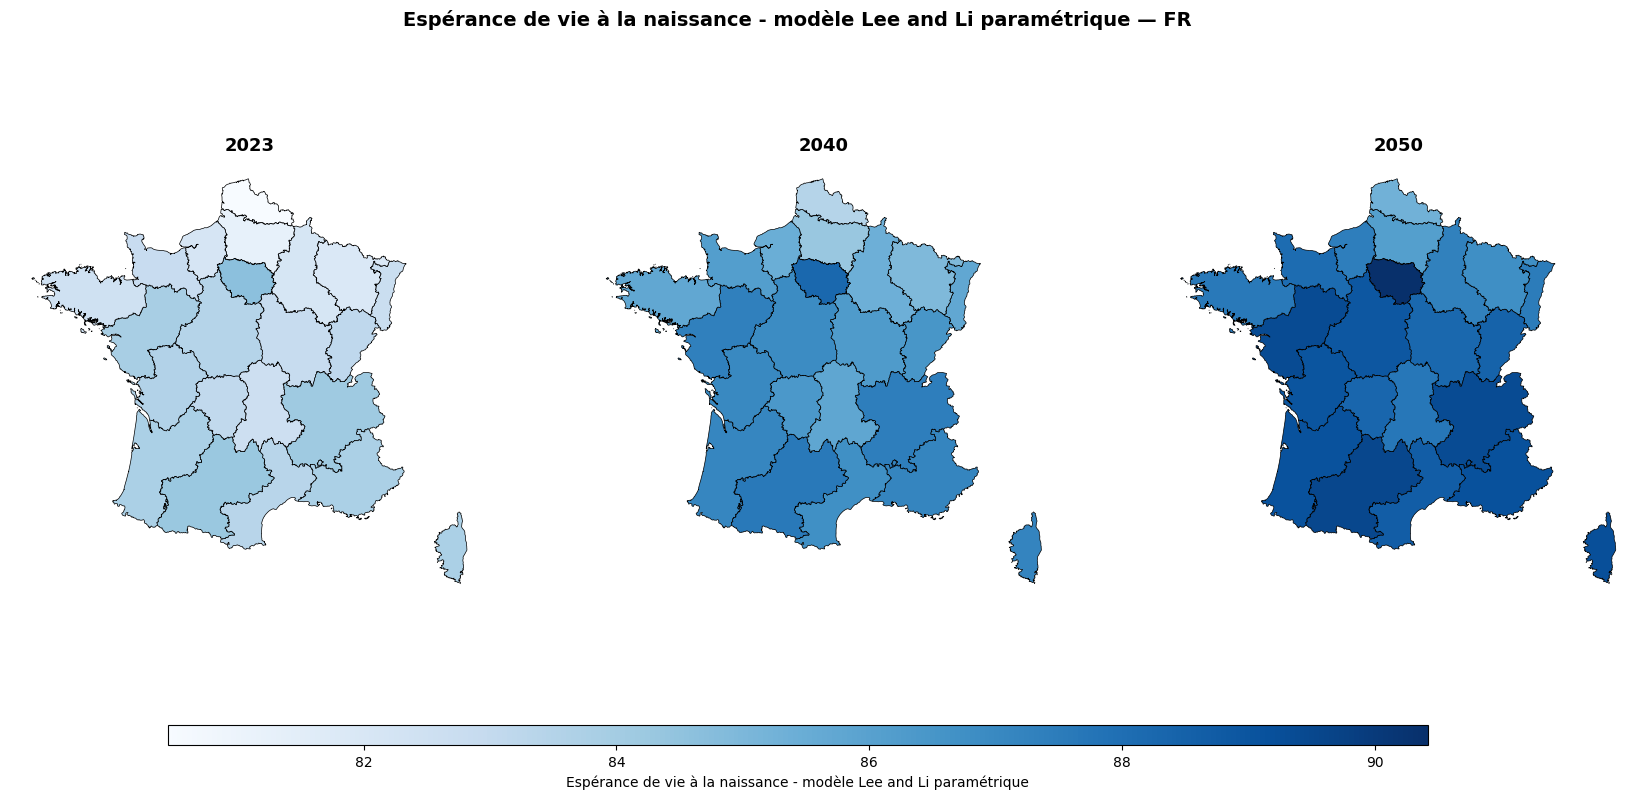

In [76]:
#Paramètre
tv_future = np.arange(1990, 2023 + 28) #années
mp = MapPlotter(regions, esp_llp, tv_future, "FR", "Espérance de vie à la naissance - modèle Lee and Li paramétrique")
#mp.plot_single_year(year=2030)
mp.plot_compare_years(years=[2023, 2040,2050])

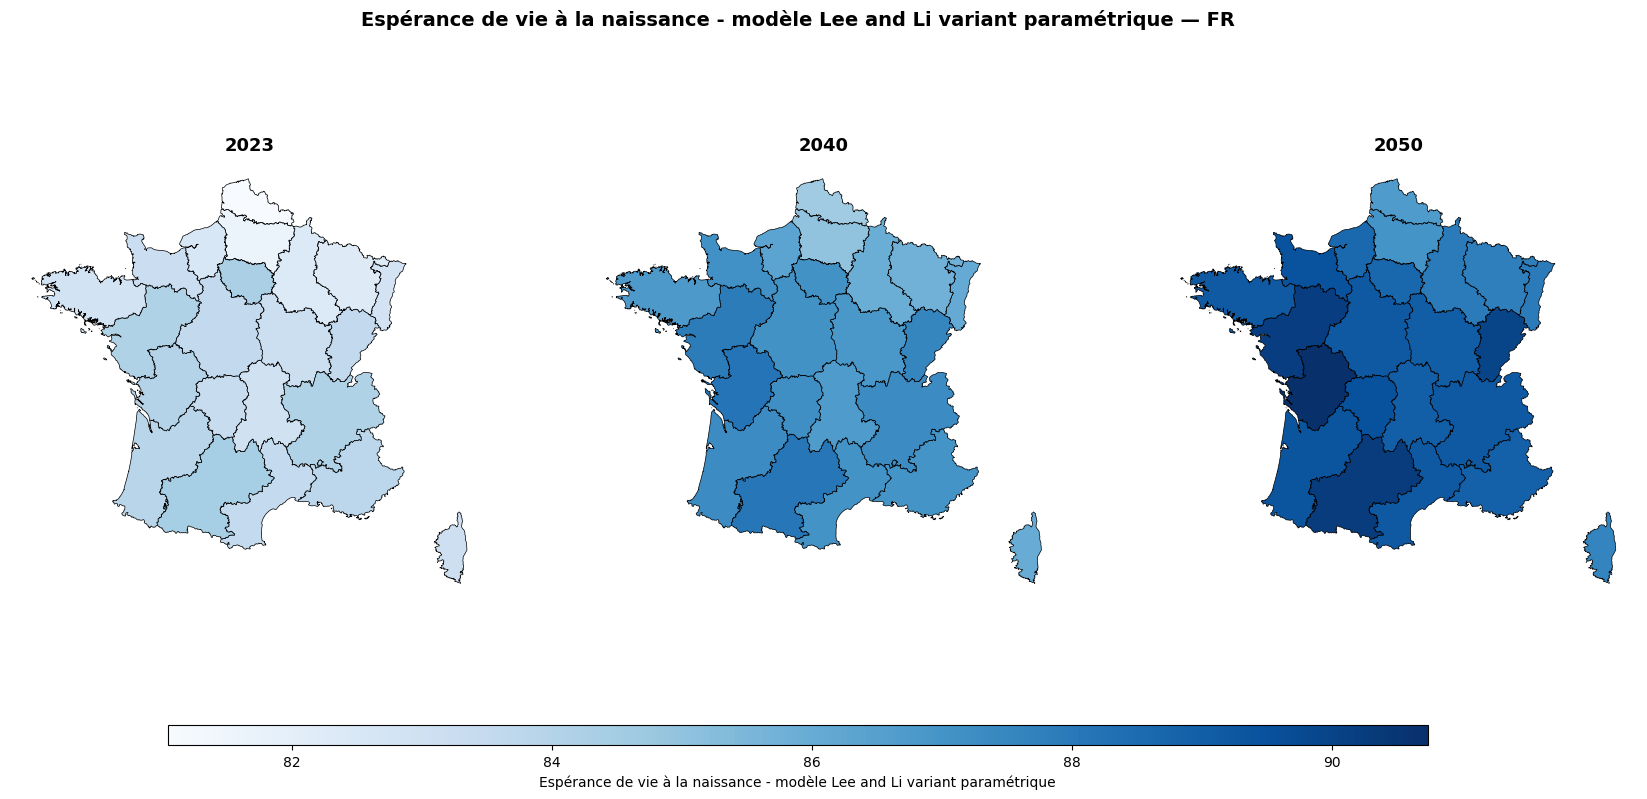

In [78]:
mp = MapPlotter(regions, esp_llp_variant, tv_future, "FR", "Espérance de vie à la naissance - modèle Lee and Li variant paramétrique")
#mp.plot_single_year(year=2030)
mp.plot_compare_years(years=[2023, 2040,2050])

#### Annuity_pricing

In [79]:
# xe = np.array([60])  # âge de souscription

# price_national = Annuity_pricing(
#     xe       = xe,
#     xv       = xv,
#     log_Muxtg = logmu_nation_lcp,  # (nb_ages, horizon, nb_reg, nb_simul)
#     duration  = 20,
#     rate      = 0.02   # taux d'actualisation à adapter
# )

# print("price shape:", price_national.shape)  # (1, nb_reg, nb_simul)

In [80]:
# price_multi = Annuity_pricing(
#     xe       = xe,
#     xv       = xv,
#     log_Muxtg = logmu_extrap_lcp,  # (nb_ages, horizon, nb_reg, nb_simul)
#     duration  = 20,
#     rate      = 0.02   # taux d'actualisation à adapter
# )

# print("price shape:", price_multi.shape)  # (1, nb_reg, nb_simul)

In [81]:
# France_nuts2 = {
#     "FR10": "IDF",        # Île-de-France
#     "FRB0": "CVL",        # Centre-Val de Loire
#     "FRC1": "BOU",        # Bourgogne
#     "FRC2": "FCO",        # Franche-Comté
#     "FRD1": "BN",         # Basse-Normandie
#     "FRD2": "HN",         # Haute-Normandie
#     "FRE1": "NPC",        # Nord-Pas de Calais
#     "FRE2": "PIC",        # Picardie
#     "FRF1": "ALS",        # Alsace
#     "FRF2": "CHA",        # Champagne-Ardenne
#     "FRF3": "LOR",        # Lorraine
#     "FRG0": "PDL",        # Pays de la Loire
#     "FRH0": "BRE",        # Bretagne
#     "FRI1": "AQU",        # Aquitaine
#     "FRI2": "LIM",        # Limousin
#     "FRI3": "POI",        # Poitou-Charentes
#     "FRJ1": "LR",         # Languedoc-Roussillon
#     "FRJ2": "MPY",        # Midi-Pyrénées
#     "FRK1": "AUV",        # Auvergne
#     "FRK2": "RA",         # Rhône-Alpes
#     "FRL0": "PACA",       # Provence-Alpes-Côte d’Azur
#     "FRM0": "COR"         # Corse
# }


# region_labels = [France_nuts2.get(r, r) for r in regions]

In [82]:
# # Cas 1 – régions seules
# AnnuityBoxPlotter(price_multi, region_labels).plot()

  

In [83]:
# # ── AnnuityBoxPlotter — one extra series ───────────────────────────
# AnnuityBoxPlotter(price_multi, region_labels, extra_series=[
#     ExtraSeries(price_national, "LC", position="last"),
# ]).plot()


In [ ]:
# lcp_mean = np.mean(esp_lcp,axis=3)
# llp_mean = np.mean(esp_llp,axis=3)

### Annexes

In [ ]:
# shapef = gpd.read_file("C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp")
# stock = "C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data"
# mxt_raw = load_mxt_raw(shapef,country="FR",data_path=stock)
# Dxt_raw = load_dxt_raw(shapef,country="FR",data_path=stock)
# Lxt_raw = load_lxt_raw(shapef,country="FR",data_path=stock)